In [1]:
# PART 1: CSV to DATA FORMATS REQUIRED BY NETWORKX

# a) Import pandas; read 'bmc_nodes.csv' as dataframe
# b) Save 'bmc_nodes' df to .json
# c) Read 'bmc_edges_2tuple.csv' as second dataframe
# d) Save 'bmc_edges_2tuple' df to tuple


# a)

import pandas as pd

df = pd.read_csv('bmc_nodes.csv')

df

,ID,label
0,Black Mountain College,1933 to 1957
1,Evelyn Anselevicius,weaver
2,Hazel Larsen Archer,"photographer, artist"
3,Ruth Asawa,"sculptor, lithographer, textile artist"
4,Harrison Begay,painter
...,...,...
114,Robert C. Turner,"ceramicist, artist"
115,Jean Varda,painter
116,Peter Voulkos,"ceramicist, painter, sculptor, artist"
117,David Weinrib,"sculptor, printmaker"


In [2]:
# b)

df.to_json('bmc_nodes.json', orient='records')

In [3]:
# c)

df2 = pd.read_csv('bmc_edges_2tuple.csv')

df2

,source,target
0,Evelyn Anselevicius,Black Mountain College
1,Hazel Larsen Archer,Black Mountain College
2,Ruth Asawa,Black Mountain College
3,Harrison Begay,Black Mountain College
4,James Bishop,Black Mountain College
...,...,...
113,Robert C. Turner,Black Mountain College
114,Jean Varda,Black Mountain College
115,Peter Voulkos,Black Mountain College
116,David Weinrib,Black Mountain College


In [4]:
# d)

edges_tuple = [tuple(x) for x in df2.values]

edges_tuple

type(edges_tuple)

list

In [5]:
# PART 2: CREATING A GRAPH IN NETWORKX

# a) import networkx and create empty graph
# b) read 'bmc_nodes.json' as dictionary
# c) add nodes dictionary to graph
# d) add edges_tuple to graph


# a)

import networkx as nx 
G = nx.Graph()

In [6]:
# b)

import json

with open('bmc_nodes.json', 'r') as file:
    nodes_dict = json.load(file)

print(nodes_dict)

[{'ID': 'Black Mountain College', 'label': '1933 to 1957'}, {'ID': 'Evelyn Anselevicius', 'label': 'weaver'}, {'ID': 'Hazel Larsen Archer', 'label': 'photographer, artist'}, {'ID': 'Ruth Asawa', 'label': 'sculptor, lithographer, textile artist'}, {'ID': 'Harrison Begay', 'label': 'painter'}, {'ID': 'James Bishop', 'label': 'painter'}, {'ID': 'John Chamberlain', 'label': 'sculptor, painter, patent inventor, photographer, draftsperson, filmmaker'}, {'ID': 'Remy Charlip', 'label': "choreographer, children's writer, theatrical director, actor, dancer, director, writer, musician, illustrator, author, designer, visual artist"}, {'ID': 'Robert Creeley', 'label': 'poet, writer, university teacher'}, {'ID': 'Fielding Dawson', 'label': 'novelist'}, {'ID': 'Elaine de Kooning', 'label': 'painter, illustrator, sculptor, architectural draftsperson, printmaker, graphic artist, art critic'}, {'ID': 'Robert De Niro Sr.', 'label': 'painter, poet, sculptor, lithographer'}, {'ID': 'Stephen De Staebler', '

In [7]:
# c) I realized that the graph could be created without a node list, so I turned off this step. I kept it in for the next phase of this project, which will involve adding node and edge descriptions and interactive hover/click elements through other Python libraries like Bokeh or seaborn

# G.add_nodes_from(['nodes_dict'])

In [8]:
# d)

G.add_edges_from(edges_tuple)

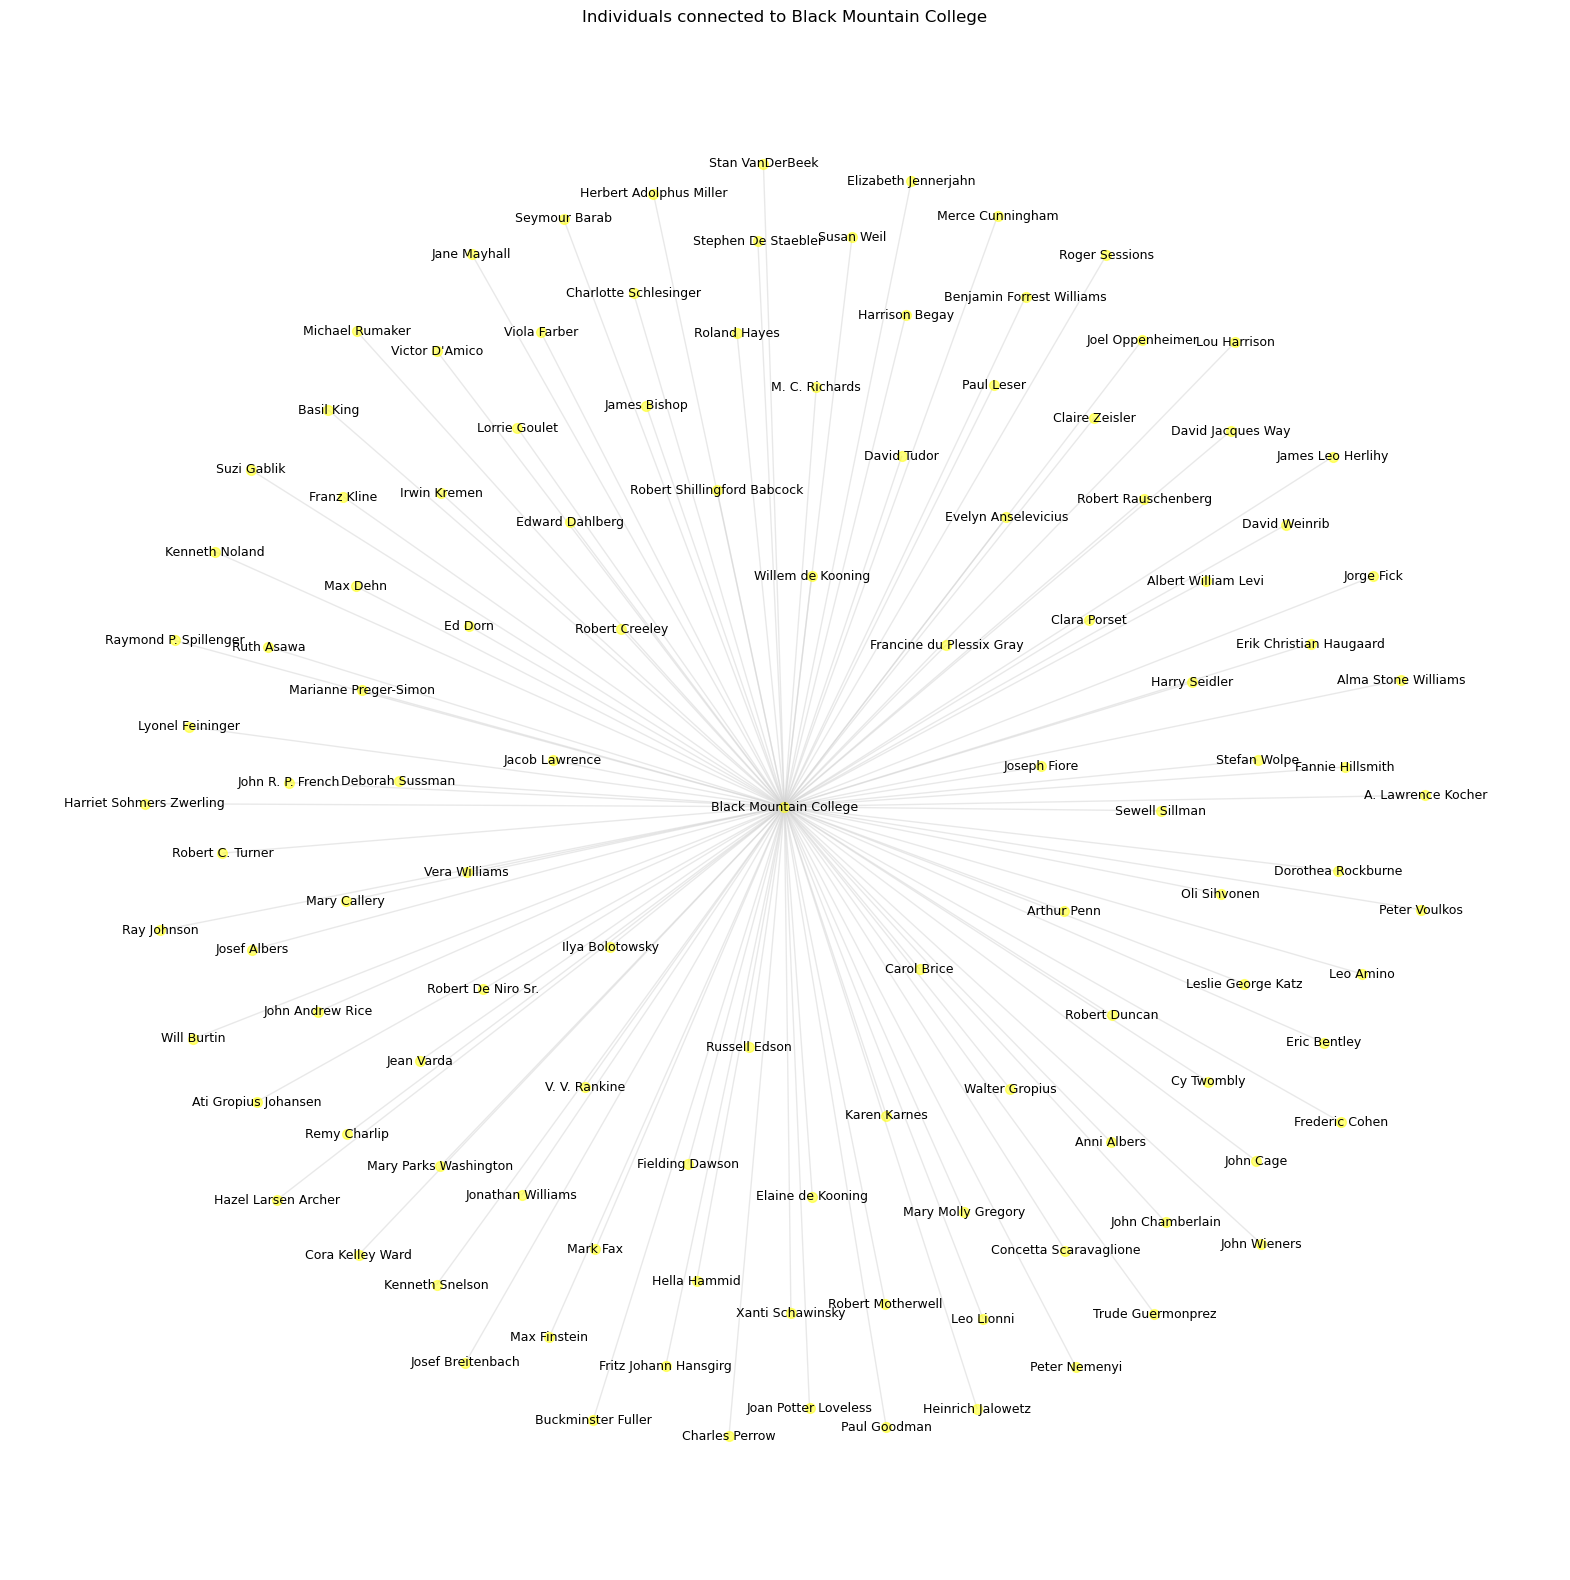

In [9]:
# PART 3: PLOT THE GRAPH

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=50, alpha=0.5, node_color='yellow')
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='lightgray')
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Individuals connected to Black Mountain College")
plt.axis('off')
plt.show()

In [10]:
# PART 4: ADD MORE CONNECTIONS

# a) read 'bmc_writers_edges-2tuple.csv' as df3
# b) read df3 as tuple
# c) add writers edges tuple to second graph
# d) plot in matplotlib


# a)

df3 = pd.read_csv('bmc_writers_edges_2tuple.csv')

df3

,Charles Olson,Robert Creeley
0,Charles Olson,Robert Duncan
1,Robert Creeley,Dan Rice
2,Charles Olson,Katherine Litz
3,Charles Olson,Merce Cunningham
4,Charles Olson,Ben Shahn
5,Merce Cunningham,John Cage
6,Merce Cunningham,Robert Rauschenberg
7,John Cage,Robert Rauschenberg
8,M. C. Richards,Merce Cunningham
9,Merce Cunningham,David Tudor


In [11]:
# b)

writers_edges_tuple = [tuple(x) for x in df3.values]

writers_edges_tuple

[('Charles Olson', 'Robert Duncan'),
 ('Robert Creeley', 'Dan Rice'),
 ('Charles Olson', 'Katherine Litz'),
 ('Charles Olson', 'Merce Cunningham'),
 ('Charles Olson', 'Ben Shahn'),
 ('Merce Cunningham', 'John Cage'),
 ('Merce Cunningham', 'Robert Rauschenberg'),
 ('John Cage', 'Robert Rauschenberg'),
 ('M. C. Richards', 'Merce Cunningham'),
 ('Merce Cunningham', 'David Tudor'),
 ('John Cage', 'Buckminster Fuller'),
 ('Merce Cunningham', 'Buckminster Fuller'),
 ('M. C. Richards', 'Fielding Dawson'),
 ('M. C. Richards', 'John Cage'),
 ('M. C. Richards', 'David Tudor'),
 ('Hilda Morley', 'Stefan Wolpe'),
 ('Charles Olson', 'Stefan Wolpe'),
 ('Robert Creeley', 'Hilda Morley'),
 ('Anni Albers', 'Josef Albers'),
 ('Robert Duncan', 'Josef Albers'),
 ('Robert Creeley', 'Denise Levertov'),
 ('Robert Creeley', 'Paul Blackburn'),
 ('Robert Duncan', 'Denise Levertov'),
 ('Robert Duncan', 'Robert Creeley'),
 ('M. C. Richards', 'Karen Karnes'),
 ('M. C. Richards', 'Lucy Rie'),
 ('John Cage', 'David 

In [12]:
# c) 

G2 = nx.Graph()

G2.add_edges_from(writers_edges_tuple)

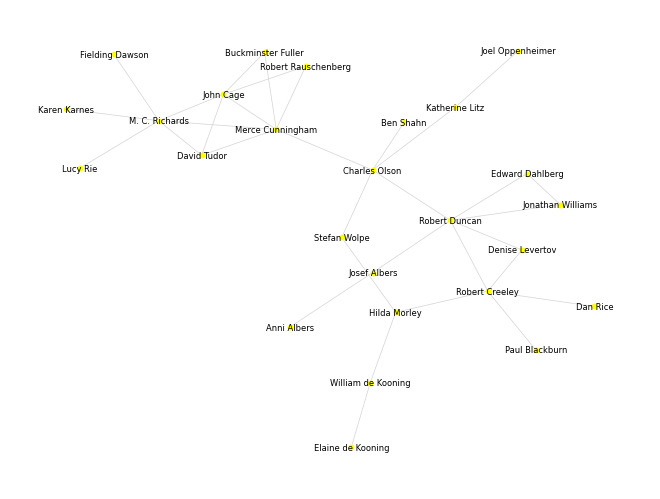

In [13]:
# d)

kwargs = {
    'node_color': 'yellow',
    'node_size': 10,
    'edge_color': 'lightgray',
    'width': 0.5,
    'with_labels': True,
    'font_size': 6,
}

nx.draw(G2, pos=nx.kamada_kawai_layout(G2), **kwargs)